In [34]:
# 1. Загрузите изображение в оттенках серого sar_1_gray.jpg. +
# 2. постройте гистограмму + 
# 3. реализуйте алгоритм гамма коррекции с параметром гамма <1, >1. + 
# 4. Сравните исходное изображение, скорректированное при помощи гамма-фильтра. MSE, SSIM.+
# 5. реализуйте алгоритм статистической цветокоррекции на основе статистики eq_gray.
# 6. Протестируйте работу алгоритмов пороговой фильтрации с различными параметрами.
# Для каждого решения - напечатайте результат

In [35]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import mean_squared_error, structural_similarity
from skimage import io, color, exposure, filters, util

<h1>1. Загрузка изображения</h1>

In [36]:
image = cv2.imread('sar_1_gray.jpg')

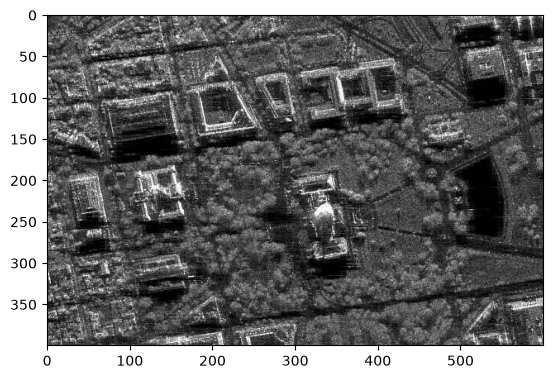

In [37]:
plt.imshow(image)

<h1>2. Гистограмма изображения</h1>

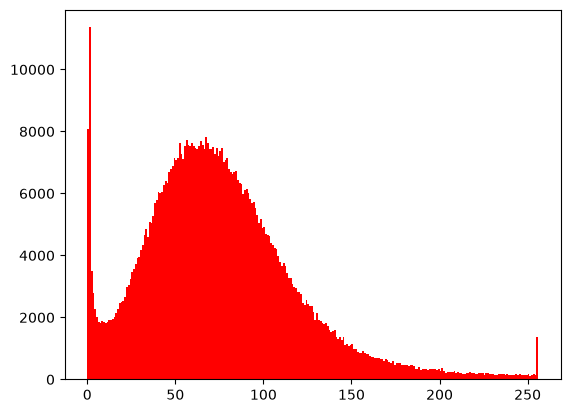

In [38]:
plt.hist(image.ravel(), bins=256, range = [0, 256], color = 'red')
plt.show()

<h1>3. Гамма коррекция</h1>

Text(0.5, 1.0, 'gamma < 1')

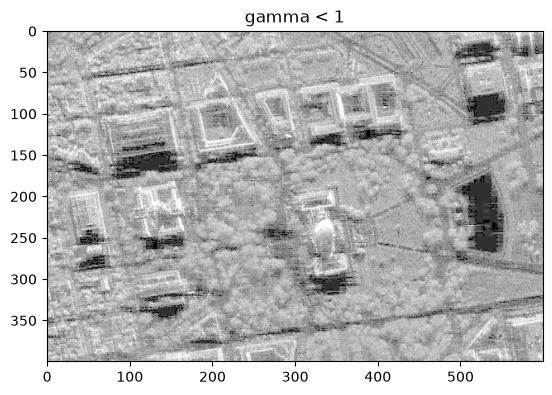

In [39]:
def gamma_correct(image, gamma):
    r_corrected = ((image / 255.0) ** gamma) * 255

    return r_corrected.astype(np.uint8)
    

img_gamma_1 = gamma_correct(image, 0.3)
plt.imshow(img_gamma_1)
plt.title('gamma < 1')

Text(0.5, 1.0, 'gamma > 1')

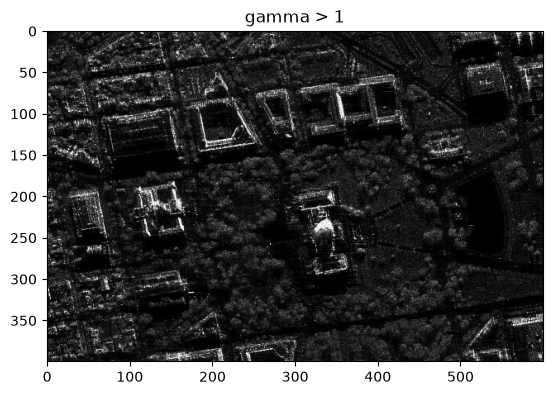

In [40]:
img_gamma_2 = gamma_correct(image, 2.0)
plt.imshow(img_gamma_2)
plt.title('gamma > 1')

<h1>4. Сравнение изображений</h1>

SSIM for gamma < 1: 0.6069559099724979



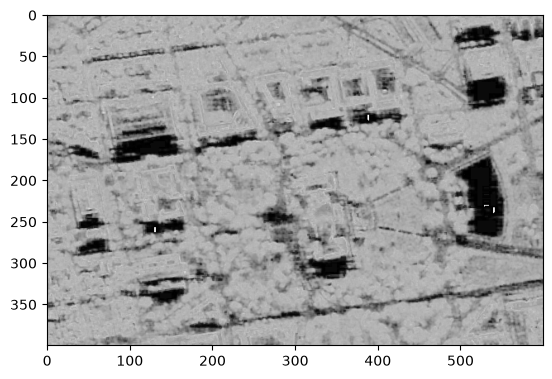

In [41]:
(ssim, diff) = structural_similarity(image, img_gamma_1, data_range=1.0, win_size=3, full= True)
diff = (diff * 255).astype("uint8")
print("SSIM for gamma < 1: {}\n".format(ssim))
plt.imshow(diff)

SSIM for gamma > 1: 0.4676667589994325



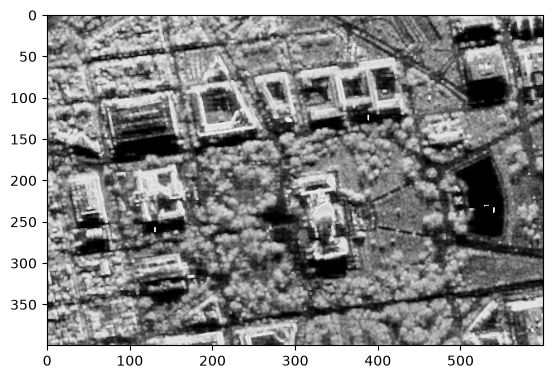

In [42]:
(ssim, diff) = structural_similarity(image, img_gamma_2, data_range=1.0, win_size=3, full= True)
diff = (diff * 255).astype("uint8")
print("SSIM for gamma > 1: {}\n".format(ssim))
plt.imshow(diff)

In [43]:
mse = mean_squared_error(image, img_gamma_1)
print("MSE for gamma < 1: {}\n".format(mse))
mse = mean_squared_error(image, img_gamma_2)
print("MSE for gamma > 1: {}\n".format(mse))

MSE for gamma < 1: 8929.8311

MSE for gamma > 1: 2383.7636375



<h1>5. Cтатистическая цветокоррекция на основе статистики eq_gray</h1>

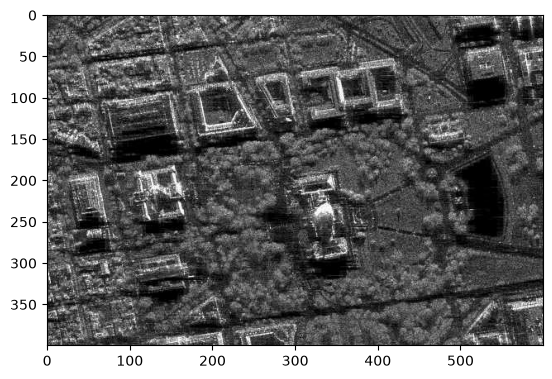

In [44]:
def color_correction_eq_gray(image):
    # 1. Переводим изображение во float, чтобы избежать искажений при делении
    img_float = image.astype(np.float32)
    
    # 2. Считаем среднее значение для каждого канала (B, G, R в OpenCV)
    # axis=(0,1) означает, что мы считаем среднее по высоте и ширине картинки
    mean_b = np.mean(img_float[:, :, 0])
    mean_g = np.mean(img_float[:, :, 1])
    mean_r = np.mean(img_float[:, :, 2])
    
    # 3. Находим общий целевой уровень серого (среднее между тремя каналами)
    mean_gray = (mean_b + mean_g + mean_r) / 3.0
    
    # 4. Вычисляем корректирующие коэффициенты для выравнивания каналов
    # Добавляем маленькое число 1e-5, чтобы защитить код от деления на ноль
    k_b = mean_gray / (mean_b + 1e-5)
    k_g = mean_gray / (mean_g + 1e-5)
    k_r = mean_gray / (mean_r + 1e-5)
    
    # 5. Применяем коэффициенты к каждому каналу по отдельности
    img_float[:, :, 0] *= k_b
    img_float[:, :, 1] *= k_g
    img_float[:, :, 2] *= k_r
    
    # 6. Ограничиваем значения в рамках [0, 255], чтобы пиксели не вышли за границы
    img_corrected = np.clip(img_float, 0, 255)
    
    # 7. Возвращаем картинку в привычный формат целых чисел (uint8)
    return img_corrected.astype(np.uint8)

result = color_correction_eq_gray(image)
plt.imshow(result)

<h1>6. Пороговая фильтрация с различными параметрами</h1>

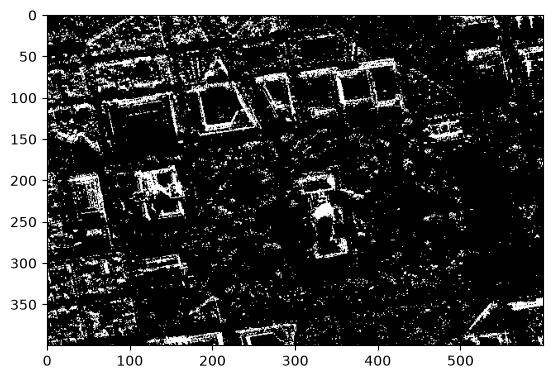

In [45]:
#Простой порог (Глобальный)
thresh_value = 127
_, thresh_global = cv2.threshold(image, thresh_value, 255, cv2.THRESH_BINARY)

plt.imshow(thresh_global)